# Phase 7 — Transfer Learning: Full Fine-Tuning

Goal: unfreeze the entire ResNet50 backbone -- every layer, not just `layer4` (Phase
6) -- and fine-tune it end-to-end alongside a fresh classifier head. The last and
least conservative of the three transfer-learning variants compared against Phase
4's from-scratch CNN in Phase 8. Same fixed split and the exact Phase 3 harness
(`src/training/`), unmodified, as every other phase.

Uses a **discriminative learning rate**, continuing Phase 6's pattern: the head
trains at `lr=1e-3` (unchanged across Phase 5/6/7), the entire backbone at `lr=1e-5`
-- 10x lower than Phase 6's `layer4` rate (`1e-4`), since now every pretrained layer
is moving, not just the last block, so it needs to move the most conservatively of
the three phases to avoid wrecking ImageNet's pretrained features before the
freshly-initialized head has learned anything useful to backpropagate.

**Status:** Done. Trained on Colab **L4** GPU (an upgrade from Phase 5/6's T4) --
test accuracy 99.78%, test macro-F1 99.69%, the best result of any phase. See the
takeaways at the bottom, and `PHASES.md`, for the full writeup and comparison
against Phase 4/5/6.

In [4]:
# Colab only: clone (or pull) the GitHub repo and cd into it. Safe to run locally
# too -- the import fails there and this cell is skipped. Repo is public, so a
# plain anonymous HTTPS clone works, no credentials needed.
try:
    import google.colab
    import os
    import shutil

    REPO_URL = "https://github.com/diljithG3/plant-disease-classification.git"
    REPO_DIR = "/content/plant-disease-classification"

    if os.path.isdir(os.path.join(REPO_DIR, ".git")):
        # A real repo from an earlier successful clone this session -- update it.
        _git_output = !git -C {REPO_DIR} pull 2>&1
    else:
        # No valid repo here yet -- possibly nothing, possibly a stray leftover
        # directory from an earlier failed attempt this session. Either way, wipe
        # it before cloning fresh: `git clone` refuses to write into a non-empty
        # directory, and re-running this cell after a failed first attempt would
        # otherwise silently take the `pull` branch above against a directory that
        # was never a real git repo, failing with "not a git repository".
        shutil.rmtree(REPO_DIR, ignore_errors=True)
        _git_output = !git clone {REPO_URL} {REPO_DIR} 2>&1

    ok = os.path.isdir(os.path.join(REPO_DIR, ".git"))
    if not ok:
        print("git clone/pull failed:")
        print("\n".join(_git_output))
        raise RuntimeError("git clone/pull failed -- see output above.")

    # os.chdir, not the %cd magic -- %cd does not reliably substitute a Python
    # variable in {}, so it was cd-ing into a literal "{REPO_DIR}" path and
    # silently failing, leaving cwd at /content.
    os.chdir(REPO_DIR)
    print("Repo ready. cwd:", os.getcwd())
except ImportError:
    pass

Repo ready. cwd: /content/plant-disease-classification


In [5]:
import sys, os

# Walk up from cwd to the project root (marked by configs/config.yaml) and put it on
# sys.path. Plain os.getcwd() is not reliable here -- it depends on how the kernel was
# launched (VS Code's Jupyter extension defaults to the notebook's own folder, not the
# project root).
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "configs", "config.yaml")):
    _parent = os.path.dirname(_root)
    if _parent == _root:
        raise RuntimeError("Could not find project root (configs/config.yaml) above " + os.getcwd())
    _root = _parent
sys.path.append(_root)

from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn

from src.utils.config import load_config
from src.utils.seed import seed_everything
from src.utils.device import get_device
from src.data import splits, transforms as T, dataset as D
from src.data.fetch_data import fetch_dataset
from src.models.transfer import build_resnet50_full_finetune
from src.training.trainer import train_model
from src.training.checkpoint import load_checkpoint
from src.training import engine
from src.training.metrics import plot_confusion_matrix

cfg = load_config()
seed_everything(cfg["seed"])
device = get_device(cfg["training"]["device"])
print("Environment:", cfg["env"], "| Device:", device)

fetch_dataset(cfg)  # no-op if already downloaded

Environment: colab | Device: cuda
Dataset already present at /content/dataset/PlantVillage/color (38 class folders). Skipping download.


PosixPath('/content/dataset/PlantVillage/color')

## 1. Load Phase 2's fixed split

Reuses the split and `class_to_idx` cached by `02_data_pipeline.ipynb` unchanged --
same requirement as every previous phase: recomputing a split here would break
comparability with every other phase (`CLAUDE.md`).

In [6]:
DATA_PATH = cfg["data"]["path"]
ARTIFACTS_DIR = cfg["data"]["artifacts_dir"]

splits_path = Path(ARTIFACTS_DIR) / "splits.csv"
class_to_idx_path = Path(ARTIFACTS_DIR) / "class_to_idx.json"

if not splits_path.exists() or not class_to_idx_path.exists():
    raise FileNotFoundError(
        f"{splits_path} or {class_to_idx_path} missing -- run notebooks/02_data_pipeline.ipynb first."
    )

splits_df = pd.read_csv(splits_path)
class_to_idx = splits.build_class_to_idx(DATA_PATH, cache_path=str(class_to_idx_path))
idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes = len(class_to_idx)

print(f"Loaded split: {len(splits_df)} images, {num_classes} classes")
splits_df["split"].value_counts()

Loaded split: 54305 images, 38 classes


,count
split,
train,38012
test,8147
val,8146


## 2. Dataloaders -- full dataset

Same fixed split, same transforms as every other phase. Meant to run on Colab GPU --
local is CPU-only, fine for the cells above but not for a real training run.

In [7]:
train_transform = T.get_train_transforms(cfg)
eval_transform = T.get_eval_transforms(cfg)

loaders = D.make_dataloaders(
    splits_df,
    class_to_idx,
    train_transform,
    eval_transform,
    batch_size=cfg["dataloader"]["batch_size"],
    num_workers=cfg["dataloader"]["num_workers"],
    data_path=DATA_PATH,
)

for split, loader in loaders.items():
    print(f"{split}: {len(loader.dataset)} images, {len(loader)} batches")

train: 38012 images, 1188 batches
val: 8146 images, 255 batches
test: 8147 images, 255 batches


## 3. Model, loss, optimizer

`build_resnet50_full_finetune` (`src/models/transfer.py`): same ResNet50 as Phase
5/6, but every parameter is trainable -- the entire backbone, not just `layer4`.

Loss is unweighted `CrossEntropyLoss`, matching every previous phase, so any
accuracy/macro-F1 difference reflects the model/training change, not a different
imbalance-handling strategy. The optimizer uses two parameter groups with a
discriminative learning rate: `fc` at `1e-3` (unchanged since Phase 5), the entire
backbone at `1e-5` -- 10x lower than Phase 6's `layer4` rate, since every
pretrained layer is moving now, not just the last block.

In [8]:
model = build_resnet50_full_finetune(num_classes).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} total (entire backbone + fc trainable)")

criterion = nn.CrossEntropyLoss()
backbone_params = [p for name, p in model.named_parameters() if not name.startswith("fc.")]
optimizer = torch.optim.Adam([
    {"params": model.fc.parameters(), "lr": 1e-3},
    {"params": backbone_params, "lr": 1e-5},
])

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 240MB/s]


Trainable parameters: 23,585,894 / 23,585,894 total (entire backbone + fc trainable)


## 4. Train

`max_epochs=30` and `early_stopping_patience: 7` on `macro_f1`
(`configs/config.yaml`) -- identical settings to every previous phase, so only the
model and optimizer's learning-rate structure differ. Note: the logged `lr` column
in the training history below reflects only the first param group (`fc`)'s
learning rate, not the backbone's -- `src/training/trainer.py` logs
`optimizer.param_groups[0]["lr"]`.

In [9]:
checkpoints_dir = Path(cfg["logging"]["checkpoints_dir"]) / "phase7_resnet50_full_finetune"
resume_path = checkpoints_dir / "last.pt"
if resume_path.exists():
    print(f"Found checkpoint from an earlier attempt, resuming from {resume_path}")

history = train_model(
    model, loaders, criterion, optimizer, device,
    run_name="phase7_resnet50_full_finetune", cfg=cfg, class_to_idx=class_to_idx, max_epochs=30,
    resume_from=resume_path if resume_path.exists() else None,
)
pd.DataFrame(history)

train:   0%|          | 0/1188 [00:00<?, ?it/s]

eval:   0%|          | 0/255 [00:00<?, ?it/s]

Epoch 0: train_loss=0.3465 val_loss=0.0725 val_acc=0.9761 val_macro_f1=0.9669 (187.4s)


train:   0%|          | 0/1188 [00:00<?, ?it/s]

eval:   0%|          | 0/255 [00:00<?, ?it/s]

...

Epoch 25: train_loss=0.0022 val_loss=0.0098 val_acc=0.9973 val_macro_f1=0.9959 (187.8s)


train:   0%|          | 0/1188 [00:00<?, ?it/s]

eval:   0%|          | 0/255 [00:00<?, ?it/s]

Epoch 26: train_loss=0.0011 val_loss=0.0080 val_acc=0.9980 val_macro_f1=0.9970 (187.6s)
Early stopping at epoch 26 (no macro_f1 improvement for 7 epochs)


,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,lr,epoch_time_sec
0,0,0.346527,0.072529,0.976062,0.966936,0.001,187.441743
1,1,0.058645,0.038198,0.986865,0.979630,0.001,187.471269
2,2,0.031927,0.029109,0.991407,0.987475,0.001,187.513699
3,3,0.022157,0.018849,0.993739,0.991576,0.001,188.009055
4,4,0.016712,0.018103,0.994353,0.992447,0.001,187.757648
5,5,0.011012,0.014266,0.995458,0.993491,0.001,188.646384
6,6,0.008816,0.022239,0.993003,0.989497,0.001,188.812460
7,7,0.006659,0.014336,0.996194,0.995240,0.001,187.802517
8,8,0.007082,0.018839,0.993616,0.989698,0.001,188.426304
9,9,0.005738,0.008904,0.996808,0.994290,0.001,187.768637


## 5. Verify checkpoint round-trip, then evaluate on the held-out test set

Same round-trip check as every previous phase: confirm `best.pt` reloads into a
**fresh** model instance and reproduces the metric it was saved with -- then use
that reloaded model for the real held-out test-set evaluation (not the val set used
during training/early stopping, which already influenced checkpoint selection).

In [10]:
checkpoints_dir = Path(cfg["logging"]["checkpoints_dir"]) / "phase7_resnet50_full_finetune"
best_path = checkpoints_dir / "best.pt"
assert best_path.exists()

fresh_model = build_resnet50_full_finetune(num_classes).to(device)
payload = load_checkpoint(best_path, fresh_model, optimizer=None, map_location=device)
assert payload["class_to_idx"] == class_to_idx, "class_to_idx did not round-trip!"
print(f"Reloaded checkpoint from epoch {payload['epoch']}, best val {cfg['training']['checkpoint_metric']}={payload['best_metric']:.4f}")

test_metrics = engine.evaluate(fresh_model, loaders["test"], criterion, device, num_classes)
print(f"Test accuracy: {test_metrics['accuracy']:.4f} | Test macro_f1: {test_metrics['macro_f1']:.4f}")

Reloaded checkpoint from epoch 19, best val macro_f1=0.9971


eval:   0%|          | 0/255 [00:00<?, ?it/s]

Test accuracy: 0.9978 | Test macro_f1: 0.9969


## 6. Confusion matrix (test set)

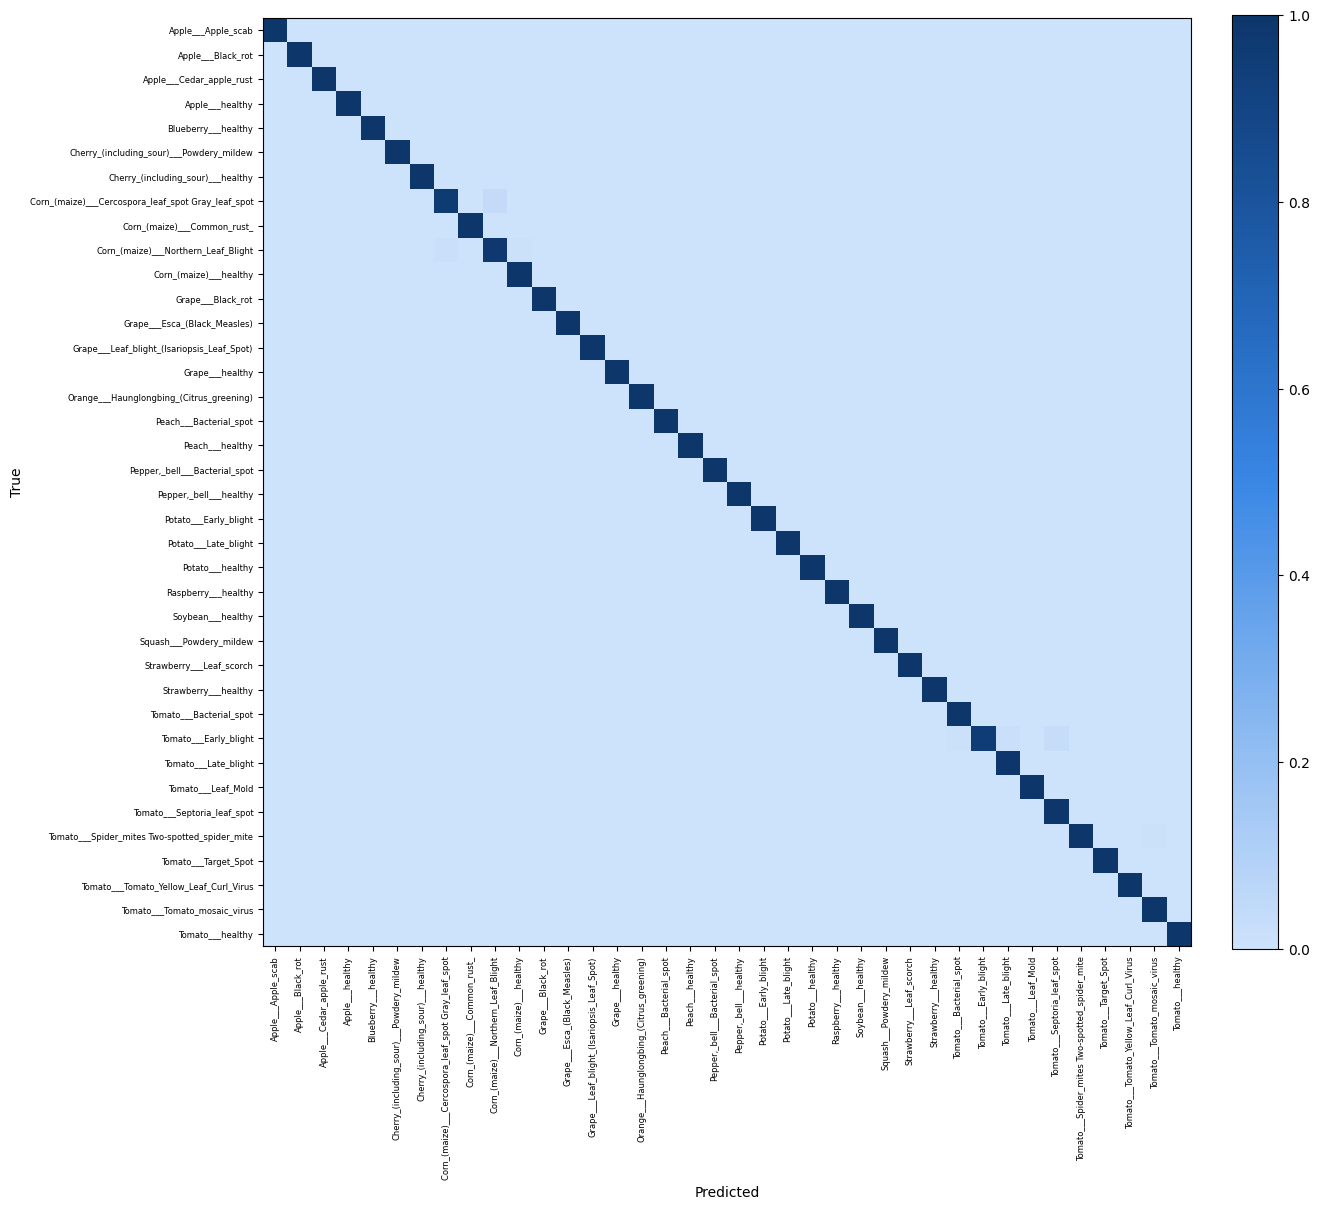

In [11]:
class_names = [idx_to_class[i] for i in range(num_classes)]
plot_confusion_matrix(test_metrics["confusion_matrix"], class_names)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

## 7. Per-class recall vs. train-set frequency

Same check every previous phase ran: does the 36x class imbalance show up in which
classes this model struggles with, and does `Corn_(maize)___Northern_Leaf_Blight`
-- Phase 6's worst class, and a class Phase 4's BatchNorm iteration also damaged --
remain difficult now that the entire backbone can adapt, not just `layer4`?

In [12]:
recall_series = pd.Series(
    test_metrics["per_class_recall"], index=[idx_to_class[i] for i in range(num_classes)]
).sort_values()

train_counts = splits_df[splits_df["split"] == "train"]["class"].value_counts()
comparison = pd.DataFrame({"train_count": train_counts, "test_recall": recall_series}).sort_values("train_count")

print("Lowest test recall (worst-performing classes):")
print(recall_series.head(10))
comparison

Lowest test recall (worst-performing classes):
Tomato___Early_blight                                 0.953333
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    0.961039
Corn_(maize)___Northern_Leaf_Blight                   0.979592
Tomato___Late_blight                                  0.989547
Tomato___Spider_mites Two-spotted_spider_mite         0.996032
Tomato___Tomato_Yellow_Leaf_Curl_Virus                0.998755
Apple___healthy                                       1.000000
Blueberry___healthy                                   1.000000
Cherry_(including_sour)___healthy                     1.000000
Corn_(maize)___Common_rust_                           1.000000
dtype: float64


,train_count,test_recall
Potato___healthy,106,1.000000
Apple___Cedar_apple_rust,192,1.000000
Peach___healthy,252,1.000000
Raspberry___healthy,260,1.000000
Tomato___Tomato_mosaic_virus,261,1.000000
Grape___healthy,296,1.000000
Strawberry___healthy,319,1.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,359,0.961039
Apple___Black_rot,435,1.000000
Apple___Apple_scab,441,1.000000


## Summary & implications for Phase 8

In [13]:
print(f"Full fine-tune test accuracy: {test_metrics['accuracy']:.4f}")
print(f"Full fine-tune test macro_f1: {test_metrics['macro_f1']:.4f}")
print(f"Worst-recall class: {recall_series.index[0]} (recall={recall_series.iloc[0]:.3f}, train_count={int(train_counts.get(recall_series.index[0], 0))})")
print(f"Best-recall class: {recall_series.index[-1]} (recall={recall_series.iloc[-1]:.3f})")

Full fine-tune test accuracy: 0.9978
Full fine-tune test macro_f1: 0.9969
Worst-recall class: Tomato___Early_blight (recall=0.953, train_count=700)
Best-recall class: Tomato___healthy (recall=1.000)


Takeaways:

- **Test accuracy 99.78%, test macro-F1 99.69% -- the best result of any phase,**
  beating Phase 6 (99.68% / 99.36%) by +0.10pp / +0.33pp. Best val macro-F1 0.9971
  at epoch 19/30; early stopping triggered at epoch 26 (7 non-improving epochs
  after epoch 19). ~85 minutes total training time over 27 epochs, averaging
  188s/epoch -- **faster per epoch than Phase 6's ~257-270s/epoch on a T4**,
  despite full fine-tuning backpropagating through 23.6M parameters vs. Phase 6's
  15.0M. Clean, direct confirmation that the L4 upgrade (used for this run only --
  Phase 5/6 both ran on T4) is a real, substantial speedup.
- **The full progression across Phase 5-7 is monotonic:** frozen backbone (97.88% /
  97.30%) -> `layer4` unfrozen (99.68% / 99.36%) -> entire backbone unfrozen
  (99.78% / 99.69%). Each additional degree of freedom to adapt pretrained features
  improved results further, and this final variant now also beats Phase 4's
  fully-iterated from-scratch CNN (98.97% / 98.46%) by +0.81pp / +1.23pp -- full
  fine-tuning is the best of all four approaches Phase 8 will compare.
- **`Tomato___Early_blight` is the worst class again** (recall 0.953, 700 train
  images) -- regressing from Phase 6's 0.993, though still far above Phase 4/5's
  ~0.77-0.82. Its usual confusion partner from Phase 4's analysis,
  `Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot`, is the second-worst here
  too (0.961). Meanwhile `Corn_(maize)___Northern_Leaf_Blight` -- Phase 6's worst
  class -- recovered strongly (0.939 -> 0.980). **These two confusion pairs
  (Early/Late blight, and the two corn diseases) keep trading off across every
  phase and variant** -- BatchNorm helped one and hurt the other in Phase 4, Phase
  6 resolved Early_blight but left Northern_Leaf_Blight weak, Phase 7 reverses that
  exact pattern. This looks like a genuine, persistent property of the data
  (visually similar diseases within the same species) rather than a fixable
  artifact of any one architecture -- worth stating plainly in Phase 8 rather than
  expecting one approach to cleanly "solve" it.
- **Imbalance still doesn't predict difficulty:** `Potato___healthy` (the smallest
  class, 106 train images) reaches a perfect 1.000 recall, same as every prior
  phase.
- Next: Phase 8 -- compare all four approaches on the identical held-out test set.
  All four results are now in hand.

## Phase 7 complete

See `PHASES.md` for the full writeup. Next: Phase 8 (compare all approaches).